![ARM Aerosol Observing System](https://armgov.svcs.arm.gov/uploads/AOS-scaled-e1753992753919.jpeg "ARM AOS")

<img src="images/arm_logo.png" width=250 alt="ARM Logo"></img>

# AOS and miniAOS bias characterization - size distributions

---

# U.S. DOE ARM Aerosol Observing System (AOS)

This notebook is a companion to `bnf-aos-miniaos-number-concentration.ipynb`. Where that
notebook compared integrated total particle number concentration $N$ between instrument
pairs, here we examine the full size-resolved number distribution $dN/d\log D_p$ to
understand whether biases are concentrated in a particular size range or are uniform across
the distribution.

Two instrument pairs are compared across the Bankhead National Forest (BNF) AMF3 deployment
from November 2024 through April 2025:

## Sub-micron: mSEMS vs. SMPS

Both instruments classify particles by **electrical mobility diameter** using a differential
mobility analyzer (DMA). Because they measure the same physical quantity, we expect close
agreement across their overlapping size range (10–337 nm); residual differences reflect
calibration offsets or flow rate drift rather than differences in sizing principle.

| Instrument | Platform | Principle | Size range | Bins |
|---|---|---|---|---|
| SMPS | AOS (reference) | Electrical mobility | 1–982 nm | 192 |
| mSEMS | miniAOS | Electrical mobility | 10–337 nm | 60 |

## Super-micron: OPC vs. APS

The OPC and APS use fundamentally different measurement principles. The APS classifies
particles by **aerodynamic diameter** (time-of-flight); the OPC classifies by **optical
diameter** (scattered-light pulse height). For the same physical particle the two diameters
differ by a factor that depends on particle density $\rho$ and dynamic shape factor $\chi$:

$$D_\text{aero} = D_\text{geo} \sqrt{\rho / (\rho_0 \chi)}$$

where $\rho_0 = 1\,\text{g}\,\text{cm}^{-3}$. Systematic offsets between OPC and APS
size distributions are therefore expected and physically meaningful.

| Instrument | Platform | Principle | Size range | Valid bins |
|---|---|---|---|---|
| APS | AOS (reference) | Aerodynamic diameter | 0.54–19.81 μm | 51 |
| OPC | miniAOS | Optical diameter | 0.27–32.4 μm | 30 (after filtering) |

## Key Reference

Uin, J., et al. (2019). Atmospheric Radiation Measurement (ARM) Aerosol Observing Systems
(AOS) for Surface-Based In Situ Atmospheric Aerosol and Trace Gas Measurements. *Journal of
Atmospheric and Oceanic Technology*, 36(12).
https://journals.ametsoc.org/view/journals/atot/36/12/jtech-d-19-0077.1.xml

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [Total-N comparison notebook](bnf-aos-miniaos-number-concentration.ipynb) | Helpful | Context for the four deployment periods and instrument overview |
| [ACT Documentation](https://arm-doe.github.io/ACT/index.html) | Necessary | Used for reading ARM NetCDF files |
| [Xarray](https://docs.xarray.dev/en/stable/) | Necessary | Dataset loading, alignment, and time selection |
| [Dask Distributed](https://distributed.dask.org/en/stable/) | Helpful | Parallel file loading via `client.map` |
| [Understanding of NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf.html) | Helpful | Familiarity with ARM data structure and metadata |
| [Aerosol Measurements: Principles, Techniques, and Applications](https://content.e-bookshelf.de/media/reading/L-587858-f097d0697a.pdf) | Helpful | Background on $dN/d\log D_p$, mobility, aerodynamic, and optical diameters |

---

## Imports

In [1]:
import act
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import align_size_distributions
import pandas as pd
from glob import glob
from scipy.interpolate import interp1d
from distributed import Client, LocalCluster, progress
from mpl_toolkits.axes_grid1 import make_axes_locatable
%matplotlib inline

## Load the Size Distribution Data

Here we load `dN/d\log D_p` from all four instrument datastreams at the BNF AMF3 site:

- **AOS SMPS** (`bnfaossmpsM1.b1`) — reference mobility size distribution, ~5-minute scans
- **AOS APS** (`bnfaosapsM1.b1`) — reference aerodynamic size distribution, 1-second resolution
- **miniAOS mSEMS** (`bnfminiaosmsemsM1.a1`) — mobility size distribution, ~64-second scans
- **miniAOS OPC** (`bnfminiaosopcM1.b1`) — optical size distribution, ~6-second resolution

All datasets are resampled to 10-minute means to reduce data volume while preserving
synoptic variability. Data are downloaded from [ARM Data Discovery](https://adc.arm.gov/discovery/).
Replace `os.environ["ARM_USERNAME"]` and `os.environ["ARM_PASSWORD"]` with your credentials.

In [ ]:
import os

act.discovery.download_arm_data(os.environ["ARM_USERNAME"], os.environ["ARM_PASSWORD"],
                                'bnfaossmpsM1.b1', '2025-11-01', '2026-04-30')
#act.discovery.download_arm_data(os.environ["ARM_USERNAME"], os.environ["ARM_PASSWORD"],
#                                'bnfaosapsM1.b1', '2025-11-01', '2026-04-30')
#act.discovery.download_arm_data(os.environ["ARM_USERNAME"], os.environ["ARM_PASSWORD"],
#                                'bnfminiaosmsemsM1.a1', '2025-11-01', '2026-04-30')
#act.discovery.download_arm_data(os.environ["ARM_USERNAME"], os.environ["ARM_PASSWORD"],
#                                'bnfminiaosopcM1.b1', '2025-11-01', '2026-04-30')

In [2]:
client = Client(LocalCluster(n_workers=8, threads_per_worker=1))
client

/Users/rjackson/miniforge3/envs/wfip3_env/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 54638 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:54638/status,
Dashboard: http://127.0.0.1:54638/status,Workers: 8
Total threads: 8,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:54639,Workers: 0
Dashboard: http://127.0.0.1:54638/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:54658,Total threads: 1
Dashboard: http://127.0.0.1:54659/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:54642,


## Helper Functions

- **`get_size_dist`** — loads `dN_dlogDp` from a single NetCDF file and resamples to
  10-minute means. Identical in structure to `get_N_conc` in the companion notebook.
- **`plot_mean_size_dist`** — plots time-mean ±1σ size distributions for two instruments
  on a shared log-diameter axis.
- **`plot_seasonal_size_dist`** — produces a 2-column panel grid of mean size distributions,
  one panel per time period, using the same four default periods as the companion notebook.

In [3]:
DEFAULT_PERIODS = [
    ("November 2024",       "2025-11-01", "2025-12-01"),
    ("Dec 2024 \u2013 Jan 2025", "2025-12-01", "2026-02-01"),
    ("Feb 2025 \u2013 Mar 2025", "2026-02-01", "2026-04-01"),
    ("April 2025",          "2026-04-01", "2026-05-01"),
]


def get_size_dist(file):
    """Load dN_dlogDp from an ARM NetCDF file, resampled to 10-minute means."""
    with act.io.read_arm_netcdf(file) as ds:
        return ds["dN_dlogDp"].resample(time="10min").mean().load()

def get_N_conc(file):
    with act.io.read_arm_netcdf(file) as ds:
        return ds['total_N_conc'].resample(time='1h').mean().load()

In [4]:
def plot_mean_size_dist(d1, dN1, d2, dN2, label1, label2,
                        xlabel="Diameter (nm)",
                        ylabel=r"$dN/d\log D_p$ ($cm^{-3}$)",
                        title="Mean Number Size Distribution",
                        color1="tab:blue", color2="tab:orange",
                        ax=None, figsize=(7, 5), show=True):
    """
    Plot time-mean dN/dlogDp for two instruments on a log-x axis.

    Parameters
    ----------
    d1 : array-like
        Diameter midpoints for instrument 1.
    dN1 : array-like
        Size distribution array, shape (time, diameter), for instrument 1.
    d2 : array-like
        Diameter midpoints for instrument 2.
    dN2 : array-like
        Size distribution array, shape (time, diameter), for instrument 2.
    label1, label2 : str
        Legend labels.
    xlabel : str, optional
        X-axis label. Default ``"Diameter (nm)"``.
    ylabel : str, optional
        Y-axis label.
    title : str, optional
        Plot title.
    color1, color2 : str, optional
        Colors for each instrument. Defaults ``"tab:blue"`` and ``"tab:orange"``.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on. If None, a new figure is created.
    figsize : tuple of float, optional
        Figure size when ax is None. Default ``(7, 5)``.
    show : bool, optional
        If True, call plt.tight_layout() and plt.show(). Default True.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    mean1 = np.nanmean(dN1, axis=0)
    std1  = np.nanstd(dN1,  axis=0)
    mean2 = np.nanmean(dN2, axis=0)
    std2  = np.nanstd(dN2,  axis=0)

    ax.semilogx(d1, mean1, color=color1, label=label1)
    ax.semilogx(d2, mean2, color=color2, label=label2)
   
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_yscale('log')
    ax.set_title(title)
    ax.legend()

    if show:
        plt.tight_layout()
        plt.show()

In [5]:
def plot_seasonal_size_dist(dN1_da, dN2_da, d1, d2, label1, label2,
                            xlabel="Diameter (nm)",
                            ylabel=r"$dN/d\log D_p$ ($cm^{-3}$)",
                            periods=None, ncols=2,
                            color1="tab:blue", color2="tab:orange", **kwargs):
    """
    Plot mean size distributions for two instruments over seasonal sub-periods.

    Parameters
    ----------
    dN1_da : xarray.DataArray
        Size distribution for instrument 1 with a datetime time coordinate.
    dN2_da : xarray.DataArray
        Size distribution for instrument 2 with a datetime time coordinate.
    d1 : array-like
        Diameter midpoints for instrument 1.
    d2 : array-like
        Diameter midpoints for instrument 2.
    label1, label2 : str
        Legend labels.
    xlabel : str, optional
        X-axis label. Default ``"Diameter (nm)"``.
    ylabel : str, optional
        Y-axis label.
    periods : list of (str, str, str), optional
        (label, start, end) tuples with half-open interval [start, end).
        Defaults to the four standard BNF deployment periods.
    ncols : int, optional
        Number of subplot columns. Default 2.
    color1, color2 : str, optional
        Colors for each instrument.
    **kwargs
        Additional keyword arguments passed to plot_mean_size_dist.
    """
    if periods is None:
        periods = DEFAULT_PERIODS

    nrows = int(np.ceil(len(periods) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.5 * nrows))

    for ax, (title, start, end) in zip(np.array(axes).flat, periods):
        dN1_sub = dN1_da.sel(time=slice(start, end)).values
        dN2_sub = dN2_da.sel(time=slice(start, end)).values
        plot_mean_size_dist(d1, dN1_sub, d2, dN2_sub, label1, label2,
                            xlabel=xlabel, ylabel=ylabel, title=title,
                            color1=color1, color2=color2,
                            ax=ax, show=False, **kwargs)

    for ax in np.array(axes).flat[len(periods):]:
        ax.set_visible(False)
        ax.set_yscale('log')

    plt.tight_layout()
    plt.show()

---

## Sub-micron Comparison: mSEMS vs. SMPS

The miniAOS **mSEMS** and the AOS **SMPS** both classify particles by electrical mobility
diameter. Their overlapping size range is 10–337 nm, which captures accumulation-mode
particles most relevant to aerosol optical depth and cloud condensation nuclei (CCN) activity.

The mSEMS stores its diameter coordinate as a 2-D `(time, bin)` array because the DMA
voltage sweep is defined per-scan. In practice the bin boundaries are highly repeatable, so
we extract the reference diameter array from the first scan of the first file and use it for
all subsequent plotting.

In [6]:
smps_list = sorted(glob("bnfaossmpsM1.b1/*.nc"))
futures = client.map(get_size_dist, smps_list)
aossmps_dN = xr.concat(client.gather(futures), dim="time").drop_duplicates("time")
futures = client.map(get_N_conc, smps_list)
aossmps_N = xr.concat(client.gather(futures), dim="time").drop_duplicates("time")
d_smps = aossmps_dN["diameter_mobility"].values  # nm, shape (192,)
aossmps_dN

<xarray.DataArray 'dN_dlogDp' (time: 25545, diameter_mobility: 192)> Size: 20MB
array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [nan, nan, nan, ..., nan, nan, nan],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]],
      shape=(25545, 192), dtype=float32)
Coordinates:
  * time               (time) datetime64[ns] 204kB 2025-11-03T15:30:00 ... 20...
  * diameter_mobility  (diameter_mobility) float32 768B 1.02 1.06 ... 982.2
Attributes:
    long_name:            Number size distribution, electrical mobility diameter
    units:                1/cm^3
    comment:              dN_dlogDp is the aerosol number size distribution w...
    ancillary_variables:  qc_dN_dlogDp

In [7]:
msems_list = sorted(glob("bnfminiaosmsemsM1.a1/*.nc"))

with act.io.read_arm_netcdf(msems_list[0]) as _ds:
    d_msems = _ds["diameter_mobility"].isel(time=0).values  # nm, shape (60,)
    dlogDp_msems = _ds["dlogDp"].isel(time=0).values
    d_msems_bounds_msems = _ds["diameter_mobility_bounds"].values
    
futures = client.map(get_size_dist, msems_list)
miniaomsems_dN = xr.concat(client.gather(futures), dim="time").drop_duplicates("time")
miniaomsems_dN
futures = client.map(get_N_conc, msems_list)
miniaomsems_N = xr.concat(client.gather(futures), dim="time").drop_duplicates("time")

In [8]:
miniaosmsems_dN_aligned, aossmps_dN_aligned = xr.align(miniaomsems_dN, aossmps_dN, exclude=["bin",
                                                                                            "diameter_mobility"])
miniaosmsems_N, aossmps_N = xr.align(miniaomsems_N, aossmps_N)
print(f"Aligned time steps: {len(aossmps_dN_aligned.time)}")

Aligned time steps: 21932


In [9]:
# Load DQRs
sheet_id = "1k_Ipo74IjrVgR8llMwzn9BCO_OepsFUFkBKI4NZp0KU"
gid = 0
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
dqrs = pd.read_csv(url)
# Load mask from Google Sheet
smps_mask = xr.ones_like(miniaosmsems_dN_aligned["time"]).astype(bool)
msems_mask = xr.ones_like(aossmps_dN_aligned["time"]).astype(bool)
for i in range(len(dqrs)):
    instrument = dqrs["Instrument"].loc[i]
    start_time = dqrs["St day/time"].loc[i]
    end_time = dqrs["End day/time"].loc[i]
    
    # Zero pad seconds if not available
    if not isinstance(start_time, str):
        continue
    start_date = start_time.split(" ")[0]
    if not "-" in start_date:
        start_date = start_date[:4] + "-" + start_date[4:6] + "-" + start_date[6:]
    start_time_hhmmss = start_time.split(" ")[1]
    if len(start_time_hhmmss.split(":")) == 2:
        start_time_hhmmss = start_time_hhmmss + ":00"
    
    start_time_hhmmss = ":".join(["%02d" % int(x) for x in start_time_hhmmss.split(":")])
    end_date = end_time.split(" ")[0]
    if not "-" in end_date:
        end_date = end_date[:4] + "-" + end_date[4:6] + "-" + end_date[6:]
    end_time_hhmmss = end_time.split(" ")[1]
    end_time_hhmmss = ":".join(["%02d" % int(x) for x in end_time_hhmmss.split(":")])
    if len(end_time_hhmmss.split(":")) == 2:
        end_time_hhmmss = end_time_hhmmss + ":00"

    if "smps" in instrument.lower():
        st = np.datetime64(start_date + "T" + start_time_hhmmss)
        ed = np.datetime64(end_date + "T" + end_time_hhmmss)
        smps_mask = xr.where(np.logical_and(smps_mask["time"] >= st, smps_mask["time"] <= ed), False, smps_mask)

    if "msems" in instrument.lower():
        st = np.datetime64(start_date + "T" + start_time_hhmmss)
        ed = np.datetime64(end_date + "T" + end_time_hhmmss)
        msems_mask = xr.where(np.logical_and(msems_mask["time"] >= st, msems_mask["time"] <= ed), False, msems_mask)

In [10]:
miniaosmsems_dN_aligned = miniaosmsems_dN_aligned.where(msems_mask)
aossmps_dN_aligned = aossmps_dN_aligned.where(smps_mask)
miniaosmsems_N_aligned = miniaosmsems_N.where(msems_mask)
aossmps_N_aligned = aossmps_N.where(smps_mask)

In [11]:
# Align SDs to the same bins (10 nm steps)
bins, miniaosmsems_dN, aossmps_dN = align_size_distributions.align_size_distributions(
    d_msems,
    miniaosmsems_dN_aligned,
    d_smps,
    aossmps_dN_aligned,
    common_bins=np.arange(0, 1000, 10))

/Users/rjackson/bnf-aos-bias-characterization/notebooks/align_size_distributions.py:48: RuntimeWarning: divide by zero encountered in log10
  log_tgt = np.log10(common_bins)


In [12]:
miniaosmsems_dN = xr.Dataset({'dN_dlogDp': (["time", "diameter_mobility"], miniaosmsems_dN), 
                              "time": miniaosmsems_dN_aligned["time"],
                              "diameter_mobility": bins})
aossmps_dN = xr.Dataset({'dN_dlogDp': (["time", "diameter_mobility"], aossmps_dN), 
                         "time": aossmps_dN_aligned["time"],
                         "diameter_mobility": bins})

In [15]:
miniaosmsems_dN["dN_dlogDp"] = miniaosmsems_dN["dN_dlogDp"].where(msems_mask)
aossmps_dN["dN_dlogDp"] = aossmps_dN["dN_dlogDp"].where(msems_mask)

## Weekly SD plots
* 1 week contour plot of SMPS and mSEMS 
* 1 weekly time series of total N between SMPS and mSEMS 
* 1 weekly ratio plot of
* Total number [10-350 nm] between mSEMS and SMPS 
* Total number [30-350 nm] between mSEMS and SMPS 
  to compare the mSEMS and SMPS without the effect of their CPCs
* Weekly scatter plot of total number 
* [10-350 nm] between mSEMS and SMPS 
* [30-350 nm] between mSEMS and SMPS 


In [21]:
i = 0
miniaosmsems_dN_aligned["bin"] = d_msems
#aossmps_dN_aligned["diameter_mobility"] = d_smps

# Mask out data gaps properly for plots
freq = "10min"  # whatever your nominal sampling interval is
full_time = pd.date_range(miniaosmsems_dN_aligned.time.min().values, 
                          miniaosmsems_dN_aligned.time.max().values, freq=freq)
miniaosmsems_dN_aligned = miniaosmsems_dN_aligned.reindex(time=full_time)
miniaosmsems_N = miniaosmsems_N.reindex(time=full_time)
aossmps_N = aossmps_N.reindex(time=full_time)
miniaosmsems_dN_aligned = miniaosmsems_dN_aligned.reindex(time=full_time)
groups_a = dict(miniaosmsems_dN_aligned.resample(time="1W"))
groups_b = dict(aossmps_dN_aligned.resample(time="1W"))

# Integrate the size distribution over the interpolated dN/dlogDp
dlogDp = np.diff(np.log10(bins))
dlogDp = np.append(dlogDp, dlogDp[-1])
dlogDp = xr.DataArray(dlogDp, dims=["diameter_mobility"])
msems_N_10_350 = (dlogDp * miniaosmsems_dN).sel(diameter_mobility=slice(10, 350.)).sum(dim="diameter_mobility")
smps_N_10_350 = (dlogDp * aossmps_dN).sel(diameter_mobility=slice(10, 350.)).sum(dim="diameter_mobility")
msems_N_30_350 = (dlogDp * miniaosmsems_dN).sel(diameter_mobility=slice(30, 350.)).sum(dim="diameter_mobility")
smps_N_30_350 = (dlogDp * aossmps_dN).sel(diameter_mobility=slice(30, 350.)).sum(dim="diameter_mobility")

# Interpolation will bring zeros instead of NaNs
msems_N_10_350 = msems_N_10_350.where(msems_N_10_350 > 0)
smps_N_10_350 = smps_N_10_350.where(smps_N_10_350 > 0)
msems_N_30_350 = msems_N_30_350.where(msems_N_30_350 > 0)
smps_N_30_350 = smps_N_30_350.where(smps_N_30_350 > 0)

# Calculate ratios
ratio_10_350 = smps_N_10_350/msems_N_10_350 
ratio_30_350 = smps_N_30_350/msems_N_30_350 
groups_c = dict(aossmps_N_aligned.resample(time="1W"))
groups_d = dict(miniaosmsems_N_aligned.resample(time="1W"))
groups_e = dict(ratio_10_350.resample(time="1W"))
groups_f = dict(ratio_30_350.resample(time="1W"))
for week in sorted(groups_a.keys() & groups_b.keys() 
                   & groups_c.keys() & groups_d.keys() & groups_e.keys() & groups_f.keys()):
    fig, ax = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
    wa, wb, wc, wd = groups_a.get(week), groups_b.get(week), groups_c.get(week), groups_d.get(week)
    we, wf = groups_e.get(week), groups_f.get(week)
    cax = [make_axes_locatable(a).append_axes("right", size="2%", pad=0.1) for a in ax]
    cax[2].set_visible(False)
    cax[3].set_visible(False)
    if wa is not None:
        np.log10(wa.T).plot.pcolormesh(
            cbar_kwargs=dict(label="$log_{10}$ dN/dlogDp \n mSEMS [$cm^{-3}]$",
                             ticks=[1, 2, 3, 4]), ax=ax[0], cbar_ax=cax[0],
            cmap="Spectral_r", vmin=0, vmax=4, levels=np.linspace(1, 4, 100))

    if wb is not None:
        np.log10(wb.T).plot.pcolormesh(
            cbar_kwargs=dict(label="$log_{10}$ dN/dlogDp \n SMPS [$cm^{-3}]$",
                             ticks=[1, 2, 3, 4]), ax=ax[1], cbar_ax=cax[1],
            cmap="Spectral_r", vmin=0, vmax=4, levels=np.linspace(1, 4, 100))

    ax[0].set_ylim([0, 1000])
    ax[0].set_ylabel("D [nm]")
    ax[1].set_ylabel("D [nm]")
    ax[0].set_xlabel("")
    ax[1].set_xlabel("")
    
    wc.plot(ax=ax[2], label="mSEMS", color='r')
    wd.plot(ax=ax[2], label="SMPS", color='b')
    ax[2].set_yscale('log')
    ax[2].set_ylim([500, 20000])
    ax[2].set_ylabel("N [$cm^{-3}$]")
    we["dN_dlogDp"].plot.scatter(ax=ax[3], label="SMPS/mSEMS 10-350 nm", color='k')
    wf["dN_dlogDp"].plot.scatter(ax=ax[3], label="SMPS/mSEMS 30-350 nm", color='r')
    ax[3].plot(we["time"], 0.8*np.ones(we.sizes["time"]), linestyle='--')
    ax[3].plot(we["time"], 1.2*np.ones(we.sizes["time"]), linestyle='--')
    ax[3].plot(we["time"], 1*np.ones(we.sizes["time"]), linewidth=1)
    ax[3].set_ylim([0, 2])
    ax[3].set_ylabel("Ratio")
    ax[2].legend()
    ax[3].legend()
    ax[2].set_xlabel("")
    ax[3].set_xlabel("Time [UTC]")
    print(week)
    time_str = str(week)
    fig.savefig(f"weekly_sd_plots/{time_str}.png", dpi=150, bbox_inches='tight')
    plt.close(fig)

/var/folders/f7/j8d4tzw924s73dlkdx4d4h_c0000gp/T/ipykernel_34079/2950458979.py:17: RuntimeWarning: divide by zero encountered in log10
  dlogDp = np.diff(np.log10(bins))
/Users/rjackson/miniforge3/envs/wfip3_env/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/Users/rjackson/miniforge3/envs/wfip3_env/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


2025-11-16T00:00:00.000000000


/Users/rjackson/miniforge3/envs/wfip3_env/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/Users/rjackson/miniforge3/envs/wfip3_env/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


2025-11-23T00:00:00.000000000


/Users/rjackson/miniforge3/envs/wfip3_env/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/Users/rjackson/miniforge3/envs/wfip3_env/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


...

2026-04-19T00:00:00.000000000


/Users/rjackson/miniforge3/envs/wfip3_env/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/Users/rjackson/miniforge3/envs/wfip3_env/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


2026-04-26T00:00:00.000000000


/Users/rjackson/miniforge3/envs/wfip3_env/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/Users/rjackson/miniforge3/envs/wfip3_env/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


2026-05-03T00:00:00.000000000


/var/folders/f7/j8d4tzw924s73dlkdx4d4h_c0000gp/T/ipykernel_83671/2439649591.py:5: RuntimeWarning: divide by zero encountered in divide
  ratio  = msems_mean / f_smps(d_msems)


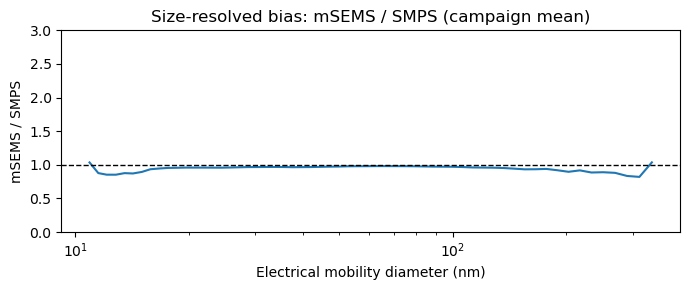

In [11]:
smps_mean  = np.nanmean(aossmps_dN_aligned.values, axis=0)
msems_mean = np.nanmean(miniaomsems_dN_aligned.values, axis=0)

f_smps = interp1d(d_smps, smps_mean, kind="linear", bounds_error=False, fill_value=np.nan)
ratio  = msems_mean / f_smps(d_msems)

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogx(d_msems, ratio, color="tab:blue")
ax.axhline(1, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("Electrical mobility diameter (nm)")
ax.set_ylabel("mSEMS / SMPS")
ax.set_title("Size-resolved bias: mSEMS / SMPS (campaign mean)")
ax.set_ylim(0, 3)
plt.tight_layout()
plt.show()

Now we split the comparison into the same four time periods used in the companion notebook
to reveal whether the size distribution agreement is stable across the deployment or
concentrated in particular seasons.

In [ ]:
plot_seasonal_size_dist(
    miniaomsems_dN_aligned, aossmps_dN_aligned,
    d_msems, d_smps,
    label1="mSEMS (miniAOS)", label2="SMPS (AOS)",
    xlabel="Electrical mobility diameter (nm)",
)

---

## Super-micron Comparison: OPC vs. APS

The miniAOS **OPC** (Optical Particle Counter) and the AOS **APS** (Aerodynamic Particle
Sizer) both span the super-micron size range but classify particles differently:

- The **APS** reports aerodynamic diameter from particle time-of-flight.
- The **OPC** reports optical diameter from scattered-light pulse height, calibrated against
  polystyrene latex spheres (refractive index \u22481.59).

Because the two diameter definitions differ by a density- and shape-dependent factor, the
distributions will be offset along the x-axis in addition to any amplitude differences.
Differences in the shape of the distributions across seasons may indicate changes in aerosol
composition (e.g. dust events shifting the super-micron mode).

The OPC `diameter_midpoint` coordinate contains two invalid bins — a duplicate value at
3.238 \u03bcm (bin 15) and a zero-valued last bin — which are removed with a monotonicity
filter after loading.

In [12]:
aps_list = sorted(glob("bnfaosapsM1.b1/*.nc"))
futures = client.map(get_size_dist, aps_list)
progress(futures)
aosaps_dN = xr.concat(client.gather(futures), dim="time").drop_duplicates("time")

d_aps = aosaps_dN["diameter_aerodynamic"].values  # um, shape (51,)
aosaps_dN

<xarray.DataArray 'dN_dlogDp' (time: 24682, diameter_aerodynamic: 51)> Size: 5MB
array([[1.42215624e+01, 1.29461775e+01, 9.37723351e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.55492659e+01, 1.34668379e+01, 9.83793640e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.54883223e+01, 1.42013969e+01, 1.01052160e+01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [2.60764289e+00, 2.19560146e+00, 1.44825411e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.36763215e+00, 1.85286117e+00, 1.14713800e+00, ...,
        0.00000000e+00, 3.19999992e-03, 0.00000000e+00],
       [2.38429737e+00, 1.83439875e+00, 1.12048757e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
      shape=(24682, 51), dtype=float32)
Coordinates:
  * time                  (time) datetime64[ns] 197kB 2025-11-01 ... 2026-04-...
  * diameter_aerodynamic  (diameter_aerodynamic) float32 204B 0.542 ... 19.81
Attributes:
    long_name:            Number size distribution, aerodynamic diameter
    units:                1/cm^3
    ancillary_variables:  qc_dN_dlogDp
    comment:              dN_dlogDp is the aerosol number size distribution w...
    equation:             (N_TOF_input / ( (total_flow_rate-sheath_flow_rate)...

In [13]:
opc_list = sorted(glob("bnfminiaosopcM1.b1/*.nc"))
futures = client.map(get_size_dist, opc_list)
progress(futures)
miniaosopc_dN = xr.concat(client.gather(futures), dim="time").drop_duplicates("time")

d_opc_all = miniaosopc_dN["diameter_midpoint"].values
valid_opc  = (d_opc_all > 0) & np.concatenate([[True], np.diff(d_opc_all) > 0])
d_opc      = d_opc_all[valid_opc]
miniaosopc_dN = miniaosopc_dN.isel(diameter_midpoint=valid_opc)

print(f"OPC valid bins: {valid_opc.sum()} of {len(d_opc_all)}, "
      f"range {d_opc[0]:.3f}\u2013{d_opc[-1]:.3f} \u03bcm")
miniaosopc_dN

OPC valid bins: 30 of 32, range 0.275–32.375 μm


<xarray.DataArray 'dN_dlogDp' (time: 22842, diameter_midpoint: 30)> Size: 3MB
array([[938.3989  , 259.06592 , 103.3358  , ...,   0.      ,   0.      ,
          0.      ],
       [952.8586  , 265.22684 , 104.45986 , ...,   0.      ,   0.      ,
          0.      ],
       [965.2442  , 265.66653 , 104.925385, ...,   0.      ,   0.      ,
          0.      ],
       ...,
       [482.78253 , 193.53658 , 111.59747 , ...,   0.      ,   0.      ,
          0.      ],
       [468.13043 , 177.52716 ,  98.74722 , ...,   0.      ,   0.      ,
          0.      ],
       [463.1977  , 170.16055 ,  92.7423  , ...,   0.      ,   0.      ,
          0.      ]], shape=(22842, 30), dtype=float32)
Coordinates:
  * time               (time) datetime64[ns] 183kB 2025-11-15 ... 2026-04-29T...
  * diameter_midpoint  (diameter_midpoint) float32 120B 0.2746 0.3239 ... 32.38
Attributes:
    long_name:  Number size distribution
    units:      1/cm^3
    comment:    dN_dlogDp is the aerosol number size distribution where the n...
    equation:   dN_dlogDp[t][b] = particle_count[t][b]/log10(diameter_midpoin...

In [14]:
miniaosopc_dN_aligned, aosaps_dN_aligned = xr.align(miniaosopc_dN, aosaps_dN)
print(f"Aligned time steps: {len(aosaps_dN_aligned.time)}")

Aligned time steps: 21663


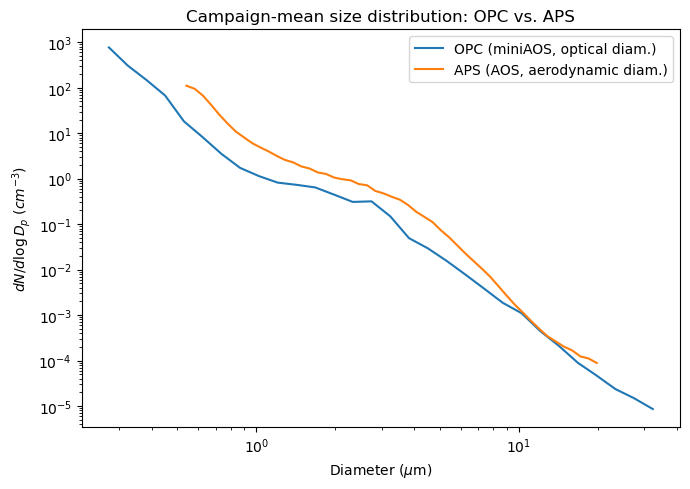

In [24]:
plot_mean_size_dist(
    d_opc, miniaosopc_dN_aligned.values,
    d_aps, aosaps_dN_aligned.values,
    label1="OPC (miniAOS, optical diam.)", label2="APS (AOS, aerodynamic diam.)",
    xlabel=r"Diameter ($\mu$m)",
    title="Campaign-mean size distribution: OPC vs. APS",
)

Because the OPC and APS report different diameter types, the ratio OPC/APS is only
physically interpretable if both distributions are placed on the same diameter axis first.
The offset between the two curves in the plot above reflects a combination of sizing
principle differences (optical vs. aerodynamic diameter) and any counting efficiency bias.
A seasonal breakdown reveals whether this offset is stable or varies with aerosol type.

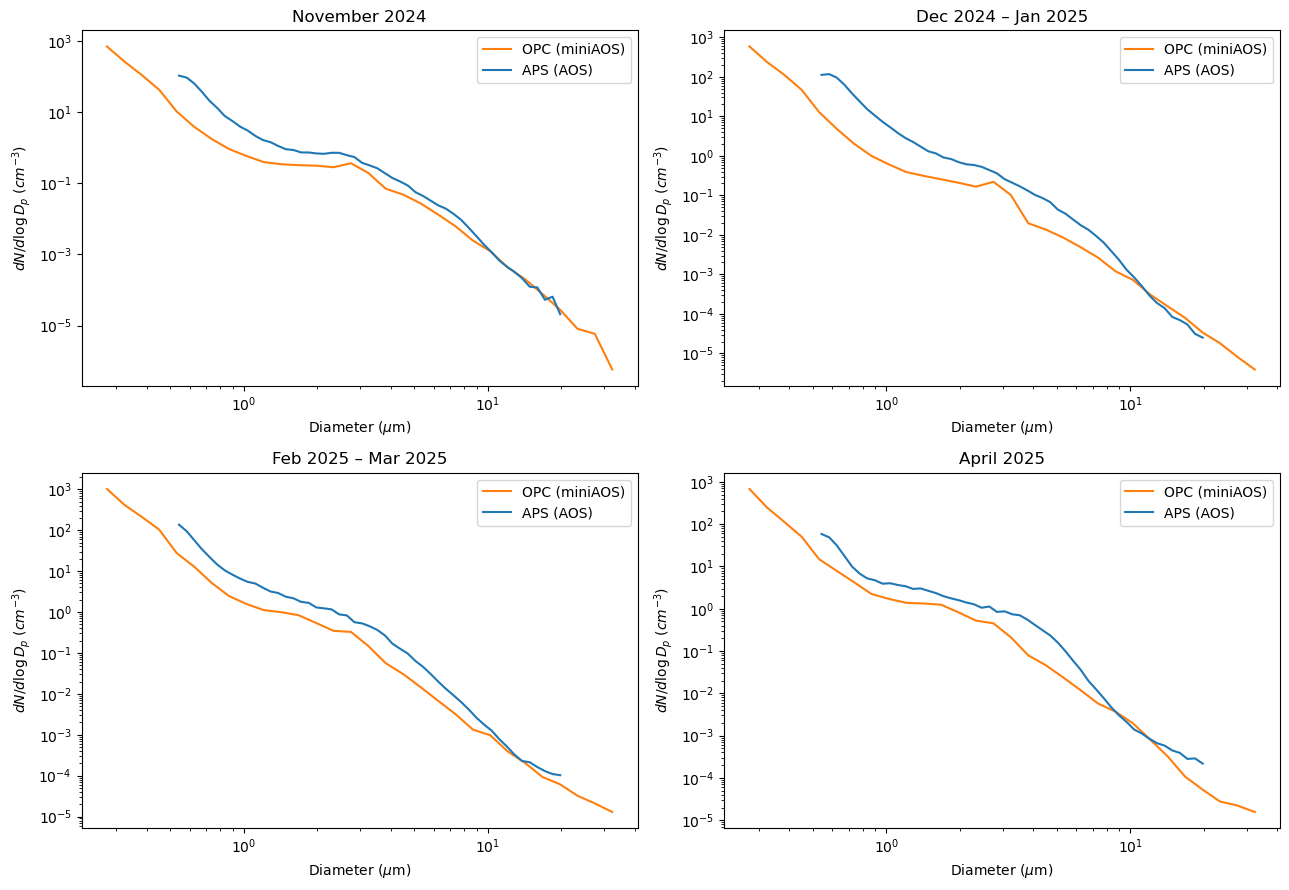

In [25]:
plot_seasonal_size_dist(
    miniaosopc_dN_aligned, aosaps_dN_aligned,
    d_opc, d_aps,
    label1="OPC (miniAOS)", label2="APS (AOS)",
    xlabel=r"Diameter ($\mu$m)",
    color1="tab:orange", color2="tab:blue",
)

---

## Summary

This notebook compared size-resolved particle number concentration ($dN/d\log D_p$) between
the ARM AOS and miniAOS instrument suites deployed at the Bankhead National Forest (BNF) AMF3
site from November 2024 through April 2025.

**Sub-micron (mSEMS vs. SMPS):** Both instruments use electrical mobility sizing. The
campaign-mean size distributions and their ratio across the overlapping 10\u2013337 nm range
quantify any size-dependent bias in the miniAOS mSEMS relative to the reference SMPS.
Departures at the smallest sizes (<30 nm) may reflect differences in charge-correction
algorithms or CPC detection efficiency.

**Super-micron (OPC vs. APS):** The OPC and APS report different diameter types (optical vs.
aerodynamic), so a systematic x-axis offset between the distributions is physically expected.
The seasonal breakdown reveals whether aerosol composition changes (e.g. higher dust loading
in spring) alter the relationship between the two instruments across the deployment period.

### What\'s next?

- Apply a density-based conversion to place OPC and APS on a common aerodynamic diameter
  axis before computing amplitudes.
- Extend the size-resolved comparison to surface area and volume distributions
  ($dS/d\log D_p$, $dV/d\log D_p$).
- Merge the SMPS and APS size distributions into a composite spectrum spanning
  ~10 nm to 20 \u03bcm.

## Resources and References

- [ARM Climate Research Facility](https://www.arm.gov)
- [ARM Data Center (ADC)](https://adc.arm.gov/discovery/) \u2014 data discovery and download
- [ACT (Atmospheric data Community Toolkit)](https://arm-doe.github.io/ACT/index.html) \u2014 ARM data I/O and analysis
- Uin, J., et al. (2019). Atmospheric Radiation Measurement (ARM) Aerosol Observing Systems (AOS) for Surface-Based In Situ Atmospheric Aerosol and Trace Gas Measurements. *Journal of Atmospheric and Oceanic Technology*, 36(12). https://doi.org/10.1175/JTECH-D-19-0077.1
- Singh, A., Kuang, C., et al. Scanning Mobility Particle Sizer (AOSSMPS), BNF. ARM User Facility. https://doi.org/10.5439/1476898
- Singh, A., Oliveira, D., et al. Aerodynamic Particle Sizer (AOSAPS), BNF. ARM User Facility. https://doi.org/10.5439/1407135
- Singh, A., Campos, D., & Subba, T. Optical Particle Counter (MINIAOSOPC), BNF. ARM User Facility. https://doi.org/10.5439/3007688